# Step - 0: Do some Prerequisite

Upload my kaggle API jesson file

In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hasnathossain","key":"4aa9defdaf7bf2e8c566287530b5fa22"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Download dataset from kaggle

In [3]:
!kaggle datasets download -d adityajn105/flickr8k


Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.03G/1.04G [00:17<00:00, 37.0MB/s]
100% 1.04G/1.04G [00:17<00:00, 61.9MB/s]


Unzip the dataset

In [4]:
!unzip -q flickr8k.zip


# Step - 01: Import all Necessary Library

In [5]:
import os
import warnings
warnings.filterwarnings('ignore') # suppressed unnecessary warning
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3 # pretained CNN Architecture/ model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing.text import Tokenizer  # convert word to integer
from tensorflow.keras.preprocessing.sequence import pad_sequences   # make caption equal length
from tensorflow.keras.utils import to_categorical, plot_model  # to_categorical: used one hot encoding output
from tensorflow.keras.models import Model, load_model    # create and load model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, add
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler # earlystopping is used to prevent overfitting
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm_notebook  # show the progess bar
from collections import Counter   # Count word frequencies in captions

# Step - 02: Load the captions and tokenize them

In [6]:
images_directory = '/content/Images/'
captions_path = '/content/captions.txt'
def load_captions(file_path):
    with open(file_path, 'r') as f:
        captions = f.readlines() # read line by line incaption
        captions = [caption.lower() for caption in captions[1:]] # convert caption into lowercase and skip the header
    return captions

def tokenize_captions(captions):
    tokenizer = Tokenizer()  # create a object of Tokenizer() calss
    tokenizer.fit_on_texts(captions) # train to learn token from caption
    return tokenizer

captions = load_captions(captions_path) # load all caption from the file
captions[:15:3]  # display every 3rd caption from the first 15 captions

['1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set of stairs in an entry way .\n',
 '1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playhouse .\n',
 '1001773457_577c3a7d70.jpg,a black dog and a tri-colored dog playing with each other on the road .\n',
 '1001773457_577c3a7d70.jpg,two dogs on pavement moving toward each other .\n',
 '1002674143_1b742ab4b8.jpg,a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .\n']

# Step - 03: Cleaning the text

One of the main steps in NLP is to remove noise so that the machine can detect the patterns easily in the text. Noise may be present in the form of special characters such as hashtags, punctuation and numbers. These are difficult for computers to understand if they are present in the text. So we need to remove these for better results.
- Additionally we can also remove stop words and perform `Stemming and Lemmatization` by using NLTK library.

In [7]:
import re
def clean_text(text):  # define a function for clean the caption
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation and spetial charaters from captions
    text = re.sub(r'\d+', '', text)  # remove numbers from captions
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces and trims the text
    return text

cleaned_captions = [clean_text(caption.split(',')[1]) for caption in captions] # extract caption text (after image name - [1]) and cleaned it
cleaned_captions[:15:2]     # Displays every 2nd caption from the first 15 cleaned captions.

['a child in a pink dress is climbing up a set of stairs in an entry way',
 'a little girl climbing into a wooden playhouse',
 'a little girl in a pink dress going into a wooden cabin',
 'a black dog and a tricolored dog playing with each other on the road',
 'two dogs of different breeds looking at each other on the road',
 'a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl',
 'a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it',
 'young girl with pigtails painting outside in the grass']

# Step - 04: Formating the Image - Captions pairs

We further process the captions by adding start and end tokens to define the sentence boundaries

In [8]:
captions_IDs = []   # create a list to store image caption pairs
for i in range(len(cleaned_captions)):
    item = captions[i].split(',')[0]+'\t'+'start '+cleaned_captions[i]+' end\n' # Extracts image ID,Adds start and end tokens to the caption,
                                                                                  # Separates image ID and caption using a tab
    captions_IDs.append(item)  # store formated image pair captions

captions_IDs[:20:3], len(captions_IDs)

(['1000268201_693b08cb0e.jpg\tstart a child in a pink dress is climbing up a set of stairs in an entry way end\n',
  '1000268201_693b08cb0e.jpg\tstart a little girl climbing the stairs to her playhouse end\n',
  '1001773457_577c3a7d70.jpg\tstart a black dog and a tricolored dog playing with each other on the road end\n',
  '1001773457_577c3a7d70.jpg\tstart two dogs on pavement moving toward each other end\n',
  '1002674143_1b742ab4b8.jpg\tstart a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it end\n',
  '1003163366_44323f5815.jpg\tstart a man lays on a bench while his dog sits by him end\n',
  '1003163366_44323f5815.jpg\tstart a shirtless man lies on a park bench with his dog end\n'],
 40455)

# Step - 05: Load some images with captions

Here we need to map the images in the training set to their corresponding descriptions which are present in our descriptions variable. Create a list of names of all training images and then create an empty dictionary and map the images to their descriptions using image name as key and a list of descriptions as its value. while mapping the descriptions add unique words at the beginning and end to identify the start and end of the sentence.

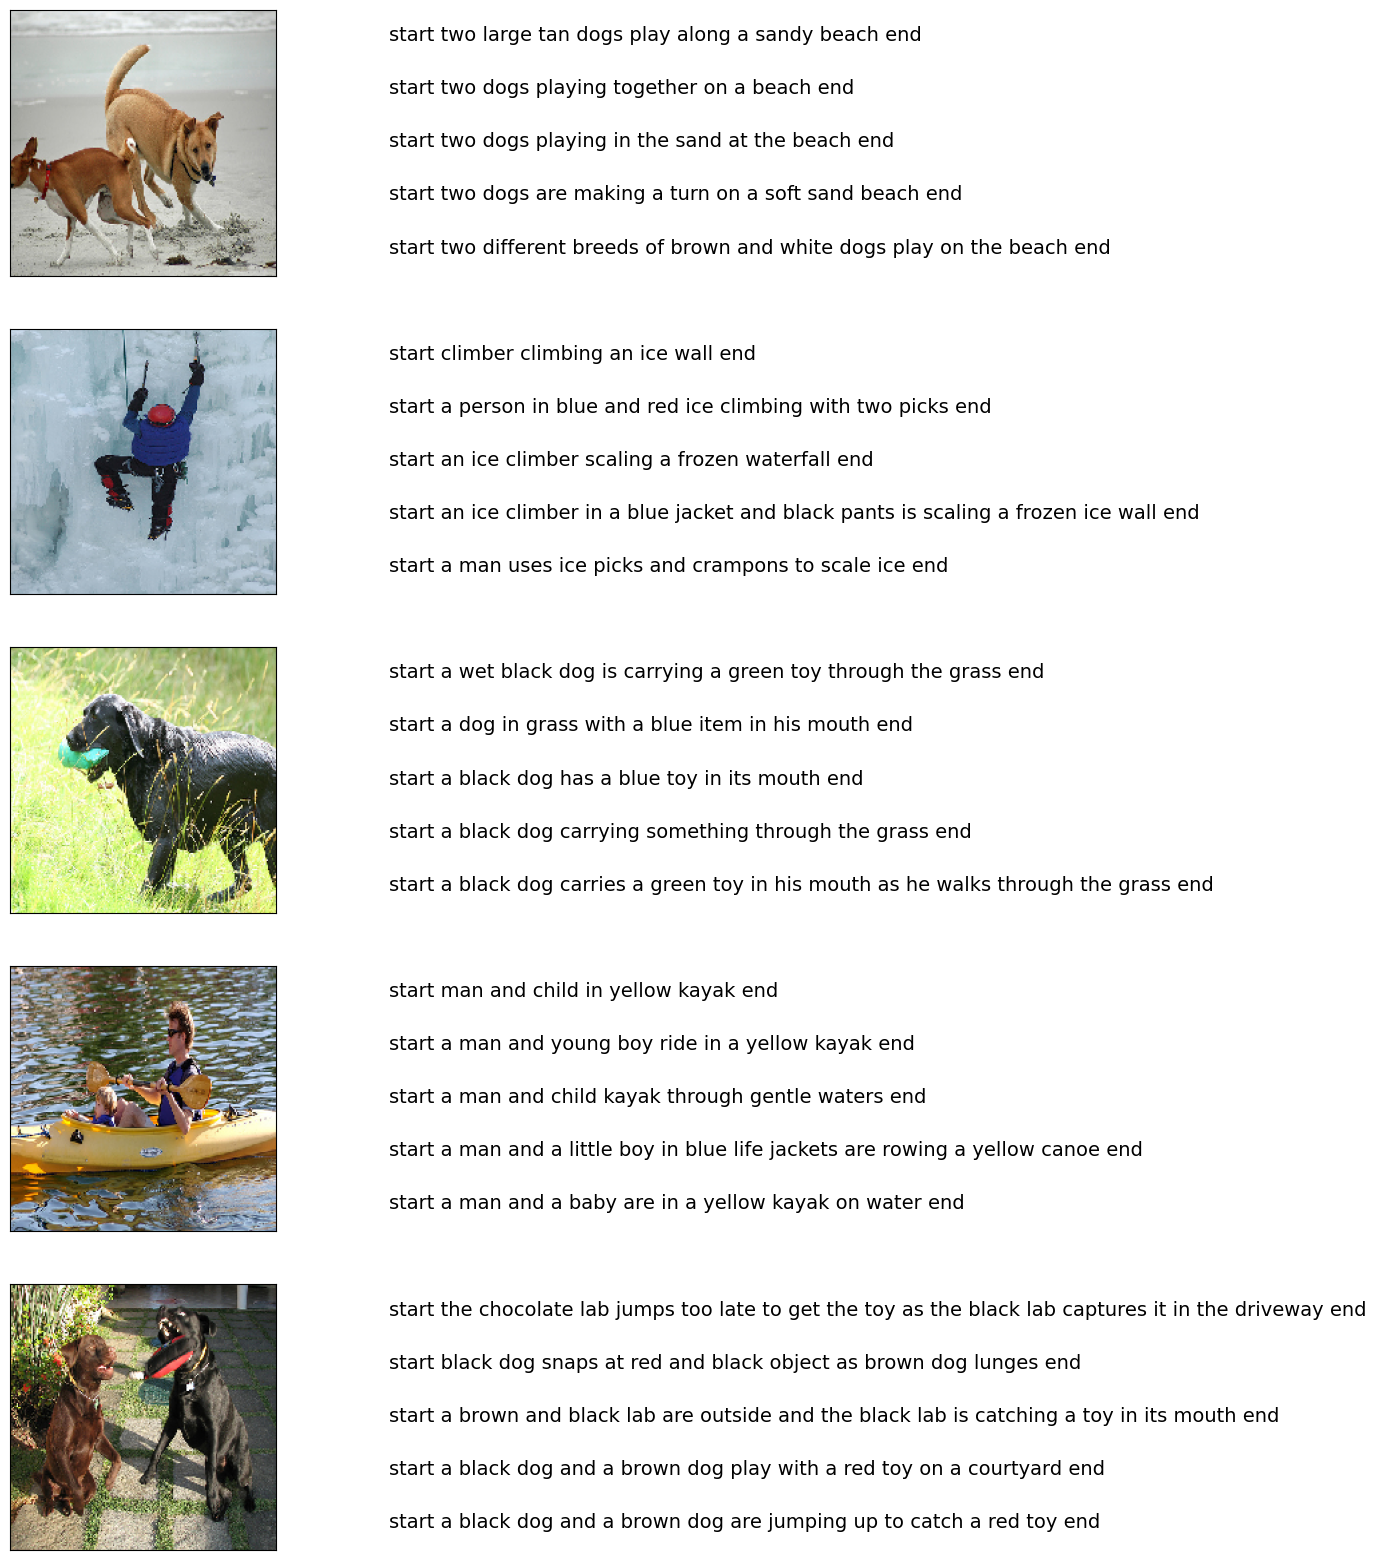

In [9]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

def visualaization(data, num_of_images):      # Function to display images with their captions.
    captions_dictionary = {}            # create a dictionary to store image id as a key and captions as value

    for item in data[100:100 + (num_of_images)*5]:   # 5 caption per image
        image_id, caption = item.split('\t')  # split image id and caption based on tab(\t)
        if image_id not in captions_dictionary:       # check and store image id in dictionary as key
            captions_dictionary[image_id] = []
        captions_dictionary[image_id].append(caption)  # collect multiple aption per image

    fig = plt.figure(figsize=(10, 20))
    count = 1

    for filename in captions_dictionary.keys():
        captions = captions_dictionary[filename]

        # ✅ FIXED PATH
        image_path = os.path.join(images_directory, filename)

        image_load = load_img(image_path, target_size=(199, 199))  # Loads and resizes image.

        ax = fig.add_subplot(num_of_images, 2, count, xticks=[], yticks=[])
        ax.imshow(image_load) # display the image
        count += 1

        ax = fig.add_subplot(num_of_images, 2, count)
        ax.axis('off')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, len(captions))

        for i, caption in enumerate(captions):
            ax.text(0, i, caption, fontsize=14) # dispaly corresponding caption as text

        count += 1

    plt.show()

# Call
visualaization(captions_IDs, 5) # call the image caption displaying function and display 5 image with caption


# Step - 06: Exploratory Data Analysis
- we will Exploring the Caption Length, Word count, Most Frequent word
- We analyze the length of captions to determine an optimal sequence length.

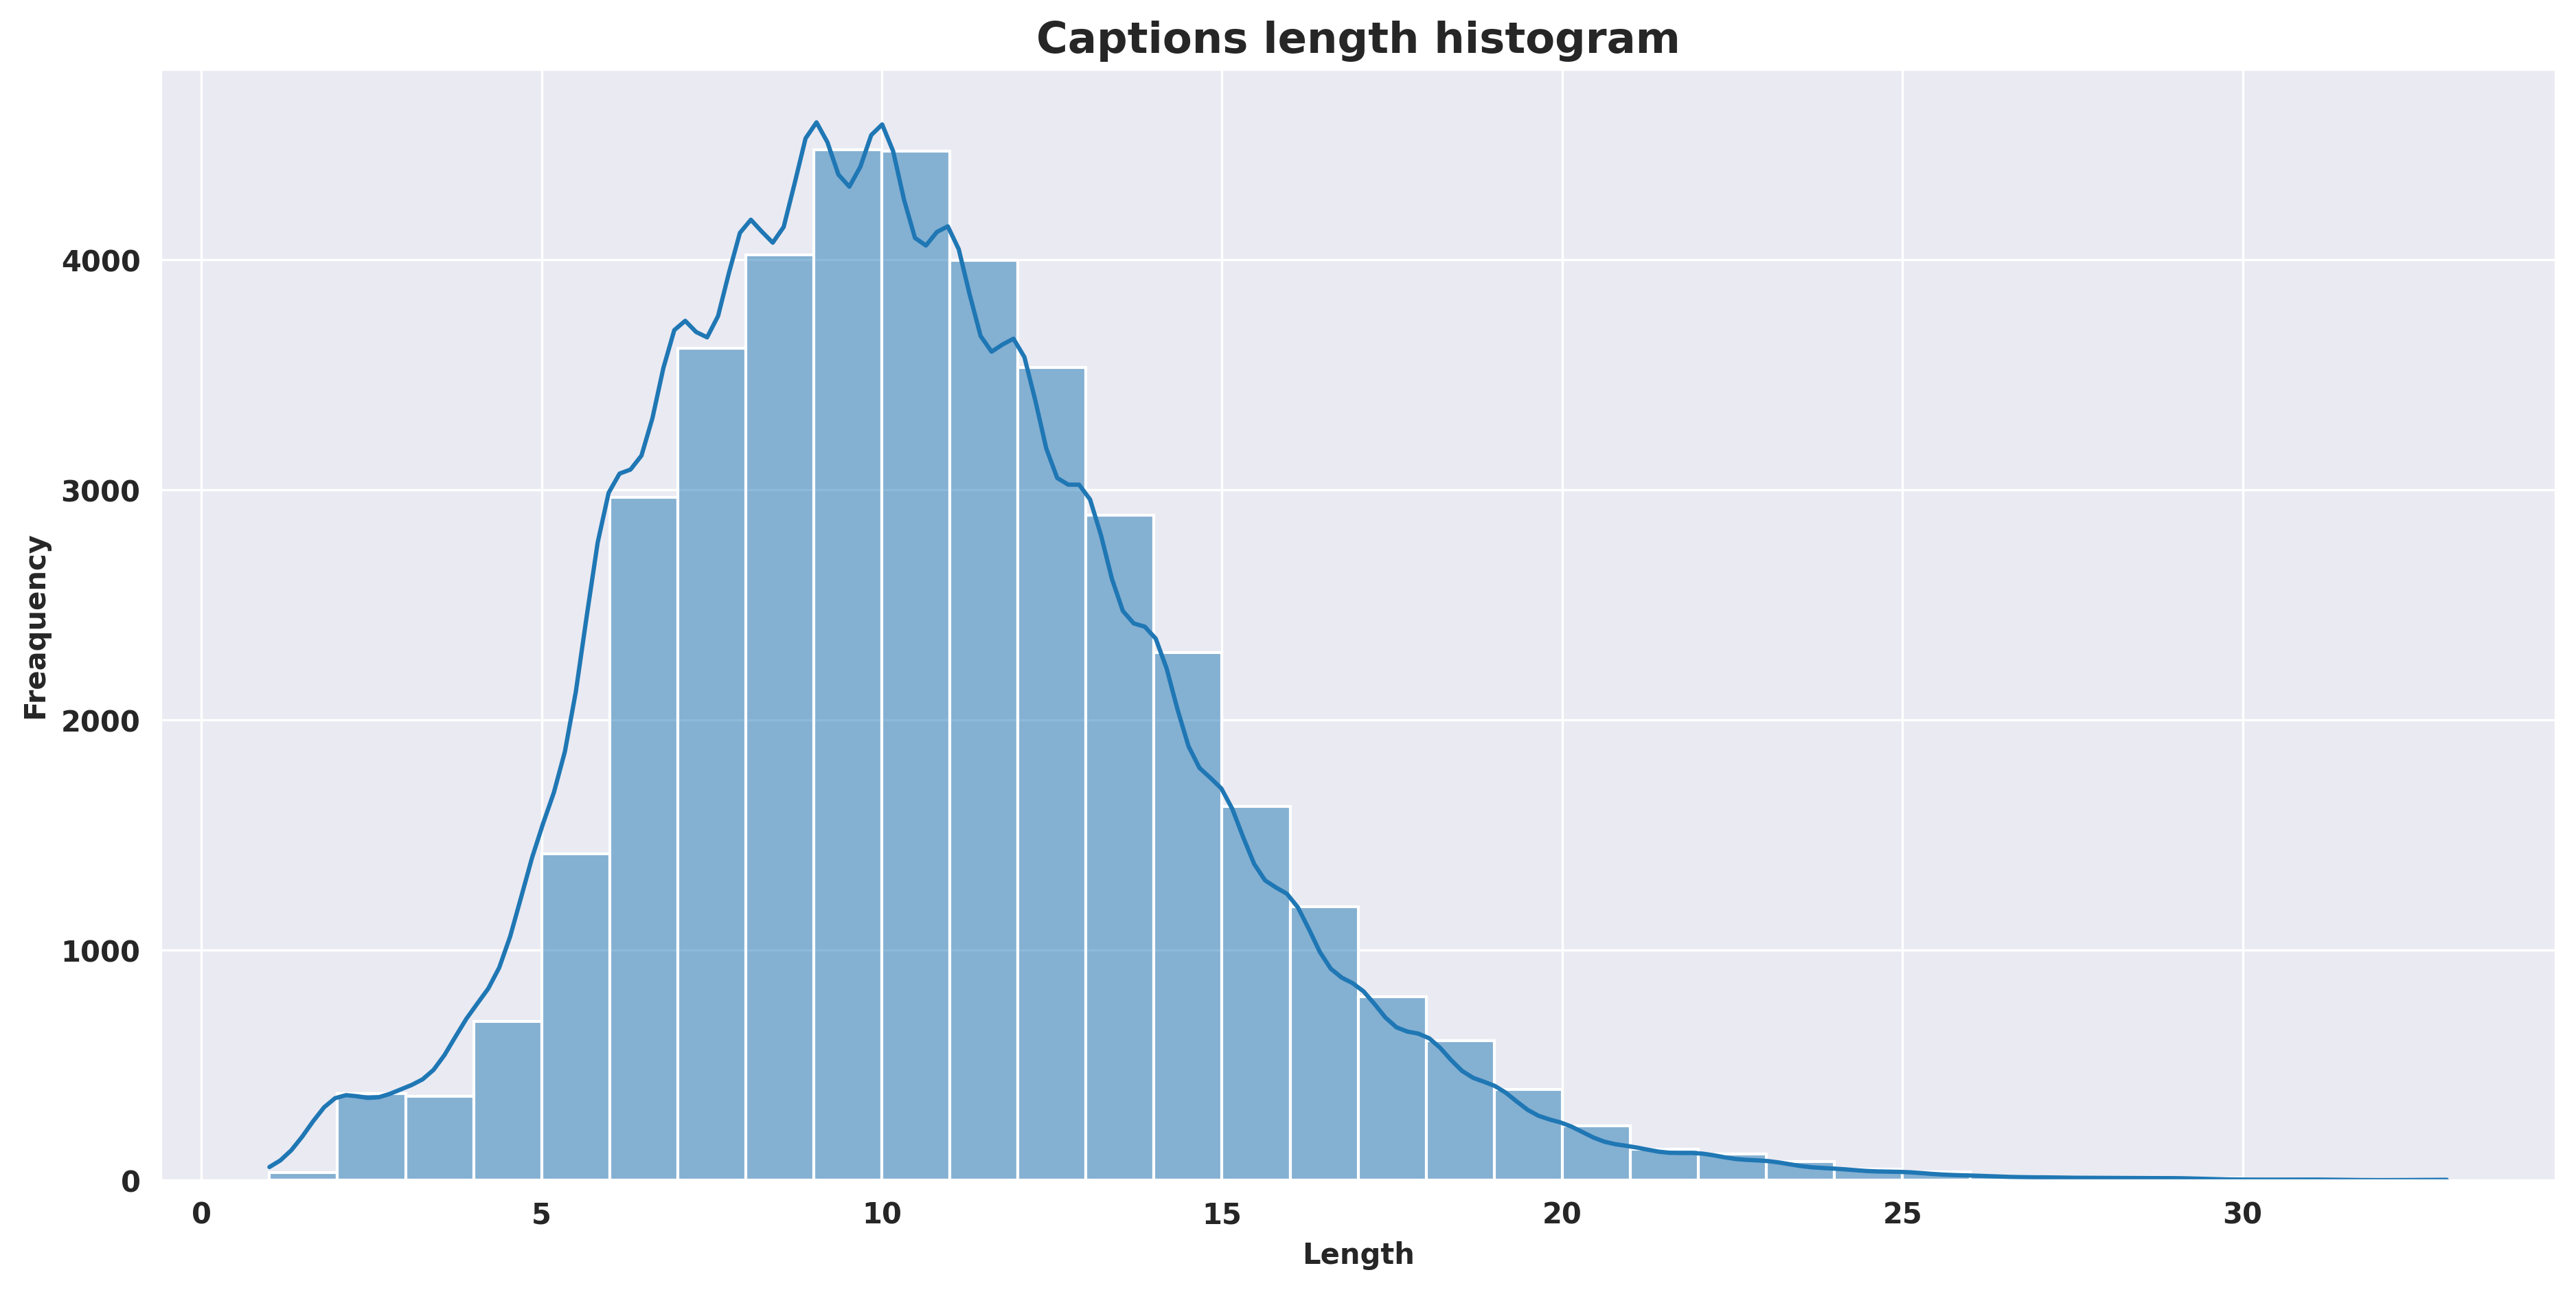

In [10]:
import seaborn as sns
def captions_length(data):
    plt.figure(figsize=(15, 7), dpi=300)
    sns.set_style('darkgrid')
    sns.histplot(x=[len(x.split(' ')) for x in data], kde=True, binwidth=1)
    plt.title('Captions length histogram', fontsize=15, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Length', fontweight='bold')
    plt.ylabel('Freaquency', fontweight='bold')
    plt.show()

captions_length(cleaned_captions)

**Box Plot – Detect Outliers (Very Important for Padding)**

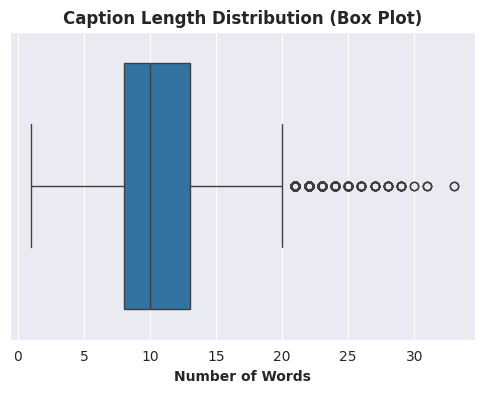

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

caption_lengths = [len(c.split()) for c in cleaned_captions]

plt.figure(figsize=(6, 4), dpi=100)
sns.boxplot(x=caption_lengths)
plt.title("Caption Length Distribution (Box Plot)", fontweight='bold')
plt.xlabel("Number of Words", fontweight='bold')
plt.show()


**Cumulative Distribution Function (CDF) – Choose MAX_LEN Scientifically**

If 95% captions ≤ 35 words, set:

max_caption_length = 35

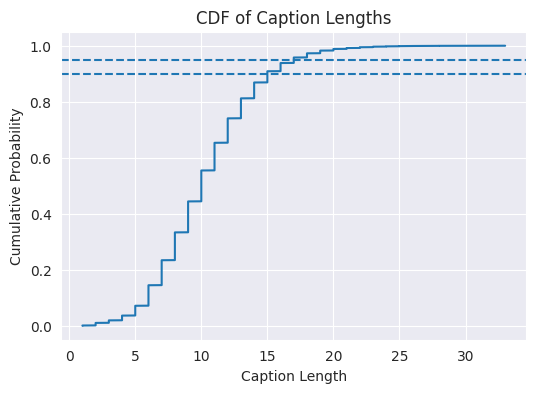

In [12]:
import numpy as np

lengths = np.array(caption_lengths)
sorted_lengths = np.sort(lengths)
cdf = np.arange(len(sorted_lengths)) / len(sorted_lengths)

# plt.figure(figsize=(10, 5), dpi=300)
plt.figure(figsize=(6, 4), dpi=100)
plt.plot(sorted_lengths, cdf)
plt.axhline(0.95, linestyle='--')
plt.axhline(0.90, linestyle='--')
plt.xlabel("Caption Length")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Caption Lengths")
plt.grid(True)
plt.show()


**Most Frequent Words (Excluding Stopwords)**
- What does the model see most often?

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


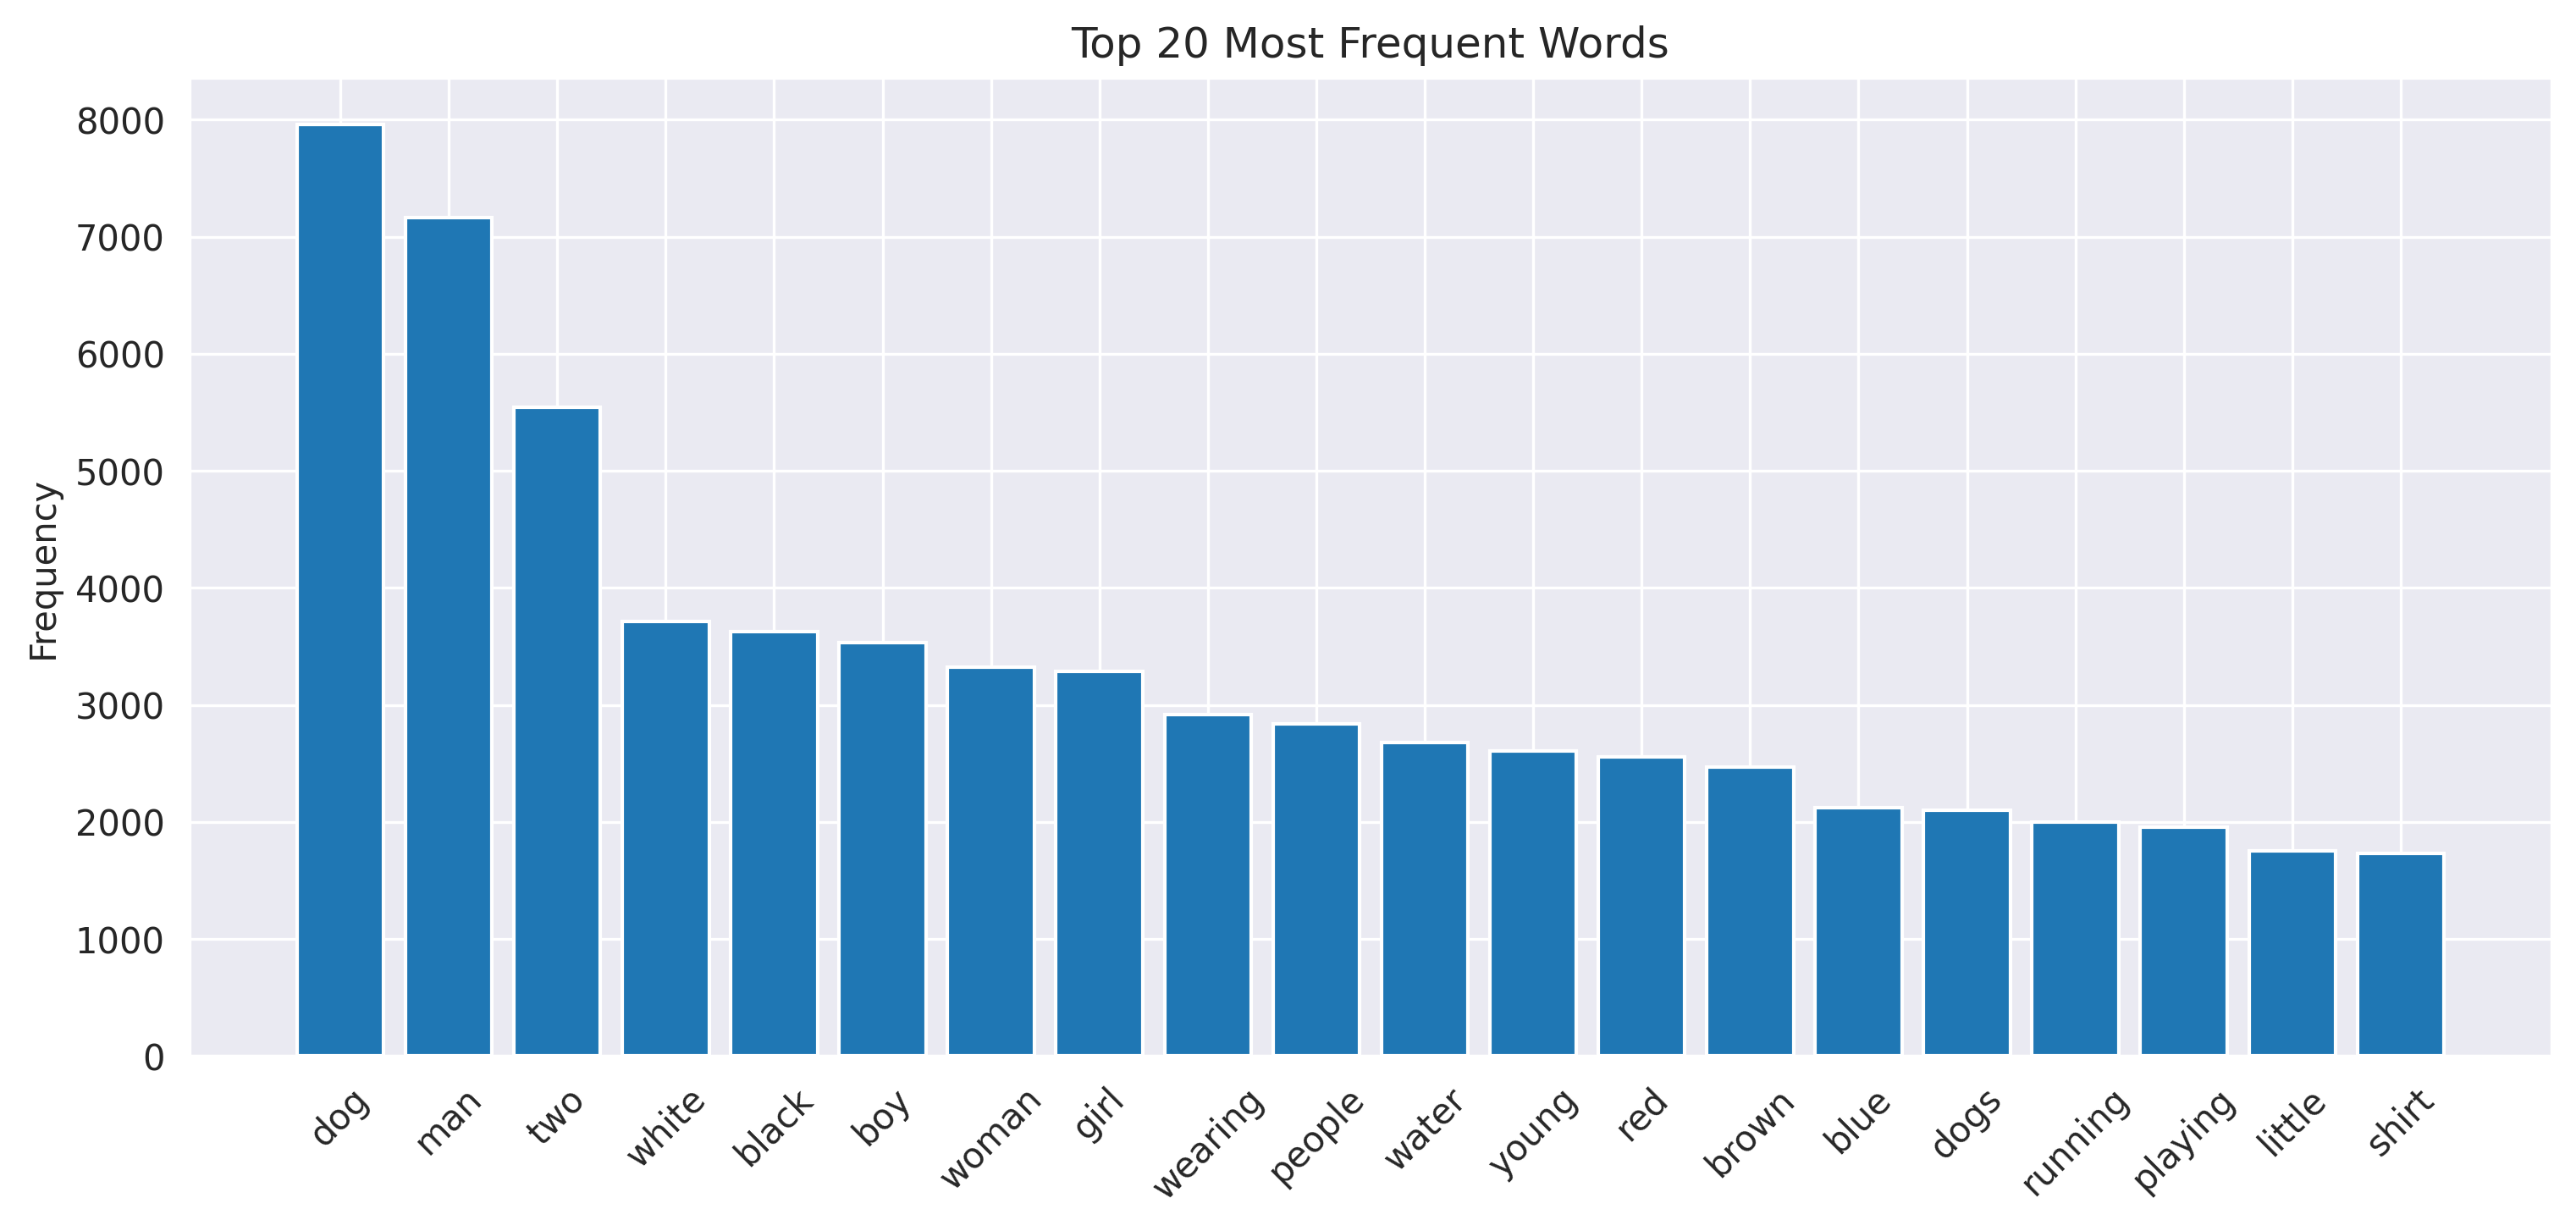

In [13]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

words = []
for cap in cleaned_captions:
    words.extend([w for w in cap.split() if w not in stop_words])

word_freq = Counter(words).most_common(20)

labels, values = zip(*word_freq)

plt.figure(figsize=(12,5), dpi=300)
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.ylabel("Frequency")
plt.show()


**POS Tag Distribution (What Kind of Words Exist in Caption?)**

- Are captions noun-heavy (objects) or verb-heavy (actions)?

- NN:	Noun (singular)	-- man, dog, ball	-- Objects in images
- NNS:	Noun (plural)	-- people, dogs	-- Multiple objects
- NNP:	Proper noun	-- John, Paris	-- Rare in Flickr8k
- VB:	Verb (base)	-- run, eat	-- Actions
- VBD:	Verb (past)	-- ran, ate	Rare
- VBG:	Verb (gerund)	-- riding, playing	-- Very common
- VBZ:	Verb (3rd person)	-- is, runs	-- Grammar
- JJ:	Adjective	-- red, small	-- Visual attributes
- RB:	Adverb	-- quickly	-- Motion description
- DT:	Determiner	-- a, the	-- Sentence structure
- IN:	Preposition	-- on, in, with	-- Spatial relations

In [14]:
import nltk

resources = ['punkt', 'stopwords', 'averaged_perceptron_tagger_eng']

for r in resources:
    try:
        nltk.data.find(f'taggers/{r}')
    except LookupError:
        nltk.download(r)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


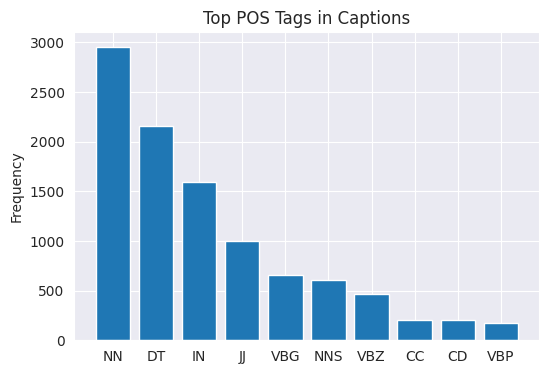

In [15]:
from nltk import pos_tag
from collections import Counter
import matplotlib.pyplot as plt

tags = []
for cap in cleaned_captions[:1000]:
    tags.extend([t for _, t in pos_tag(cap.split())])

tag_freq = Counter(tags).most_common(10)
labels, values = zip(*tag_freq)

# plt.figure(figsize=(10,5), dpi=300)
plt.figure(figsize=(6,4), dpi=100)
plt.bar(labels, values)
plt.title("Top POS Tags in Captions")
plt.ylabel("Frequency")
plt.show()


Word Cloud (Semantic Overview)
- What concepts dominate the dataset?
- quick visual overview of important word
- helps to identify key themes of the dataset

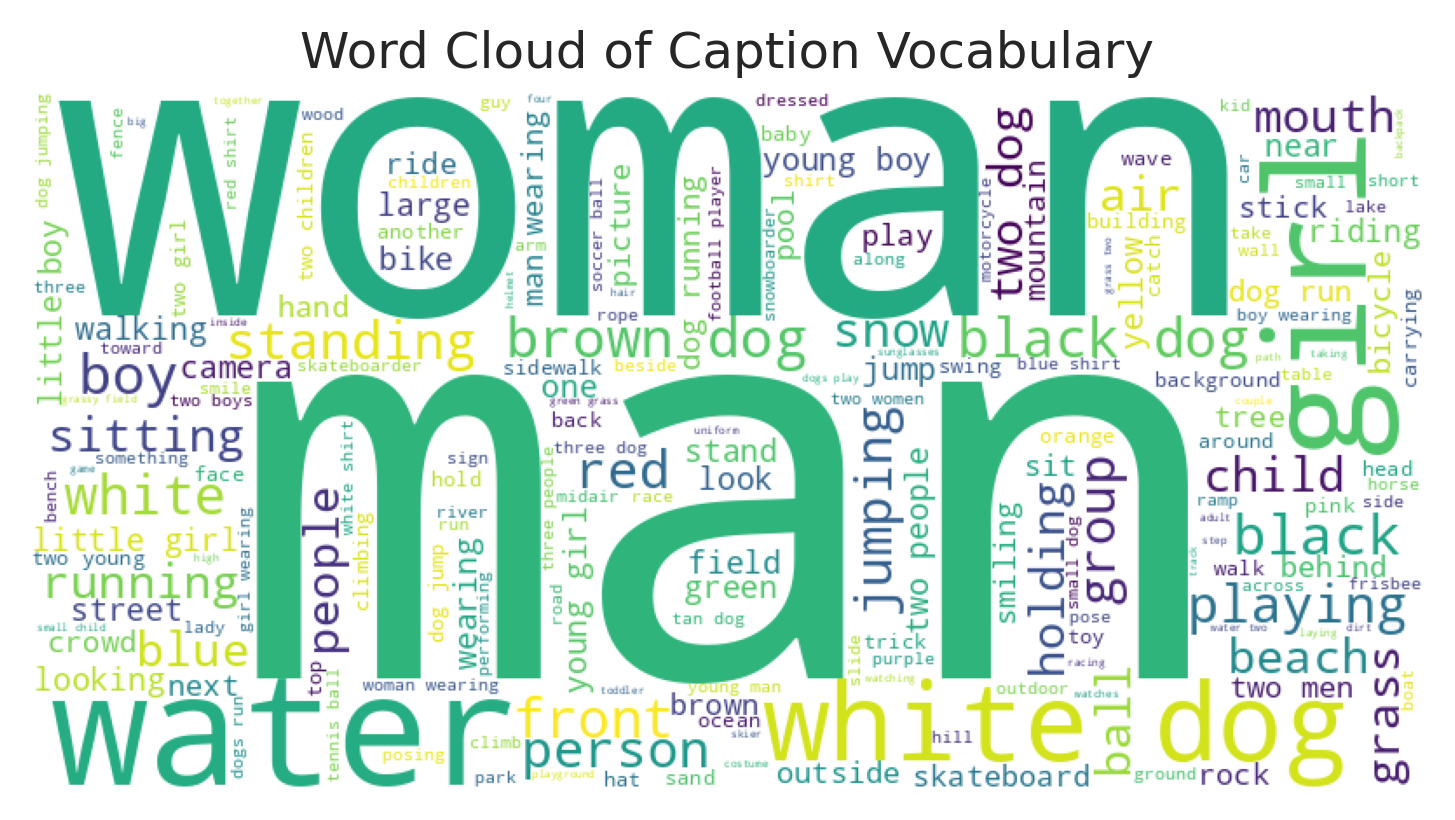

In [16]:
from wordcloud import WordCloud

text = " ".join(cleaned_captions)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)
# figsize(width,height)

plt.figure(figsize=(6,6), dpi=300)
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Caption Vocabulary")
plt.show()


# Step - 07: Tokenizing the vocabulary

We will use Keras Tokenizer to convert text data into numerical sequences.

Purpose:

1. Neural networks can’t understand text directly.
Tokenizer converts words → integers.
Why needed in image captioning:

2. We train a model to predict sequences of numbers.
Later, at inference time, the model generates indices → words

In [17]:
tokenizer = tokenize_captions(cleaned_captions) # Creates and fits a tokenizer on all cleaned captions to build the vocabulary.
vocab_size = len(tokenizer.word_index) + 1
vocab_size # we have total 8586 vocabulary that's why we used 8586 node in LSTM output (softmax)

8586

# Step - 08: Splitting the dataset into train, validation and test sets

We divide our dataset into training, validation and testing subsets.

Purpose of splitting:

- Training set → Used to train the model
- Validation set → Used to tune hyperparameters and check performance during training
- Test set → Used to evaluate final model performance

Why it matters in image captioning:

- Each image has multiple captions
- We split at the image level, not caption level, to avoid data leakage.

What this code achieves:

- Randomly splits images into 3 sets
- Assigns all captions of each image to the same set
- Prints the first captions and number of images in each split




In [18]:
all_image_ids = os.listdir(images_directory)

train_image_ids, val_image_ids = train_test_split(all_image_ids, test_size=0.15, random_state=42)
val_image_ids, test_image_ids = train_test_split(val_image_ids, test_size=0.2, random_state=42)

train_captions, val_captions, test_captions = [], [], []
for caption in captions_IDs:
    image_id, _ = caption.split('\t')

    if image_id in train_image_ids:
        train_captions.append(caption)

    elif image_id in val_image_ids:
        val_captions.append(caption)

    elif image_id in test_image_ids:
        test_captions.append(caption)

    else:
        print('Unknown image ID !')

train_captions[0], val_captions[0], test_captions[0], len(train_captions)/5, len(val_captions)/5, len(test_captions)/5

('1000268201_693b08cb0e.jpg\tstart a child in a pink dress is climbing up a set of stairs in an entry way end\n',
 '1003163366_44323f5815.jpg\tstart a man lays on a bench while his dog sits by him end\n',
 '1096395242_fc69f0ae5a.jpg\tstart a boy with a toy gun end\n',
 6877.0,
 971.0,
 243.0)

# Step - 09: Using InceptionV3 CNN model we Extract the feature vector from all images


- Machines cannot understand raw images like humans.
- Use a pre-trained CNN (InceptionV3) as a feature extractor.

Steps:
- Preprocess the image
- Pass through InceptionV3 (without the last layer)
- Get 2048-dimensional feature vector representing the image

Purpose in image captioning:

- Feature vector is input to the caption generator (LSTM)
- Model learns to generate words based on the image representation

In [19]:
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img  # return preprocessed image for feature extraction

def extract_image_features(model, image_path):
    img = preprocess_image(image_path)
    features = model.predict(img, verbose=0)
    return features

inception_v3_model = InceptionV3(weights = 'imagenet', input_shape=(299, 299, 3)) # Loads pretrained InceptionV3 model with ImageNet weights.
inception_v3_model.layers.pop()       # Removes the final classification layer (we don’t need 1000 ImageNet classes).
inception_v3_model = Model(inputs=inception_v3_model.inputs, outputs=inception_v3_model.layers[-2].output)  # Creates a feature extractor model that outputs the image embedding (second last layer).

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Step - 10: Extracting Image Features for Training, Validation and Testing

To train our Image Caption Generator, we need to extract feature vectors from images using the pre-trained InceptionV3 model. These features will serve as inputs to our captioning model. We store the extracted features in dictionaries corresponding to training, validation, and testing datasets.

In [20]:
from tqdm.notebook import tqdm

# Dictionaries to store features
train_image_features, val_image_features, test_image_features = {}, {}, {}

# Loop over all image files
pbar = tqdm(total=len(all_image_ids), position=0, leave=True, colour='green') # Creates a progress bar for tracking feature extraction.

for image_id in all_image_ids:  # just the file names
    image_path = os.path.join(images_directory, image_id)
    features = extract_image_features(inception_v3_model, image_path).flatten()  # Extract feature and Flatten to 2048 vector
# Stores features in the appropriate dataset dictionary.
    if image_id in train_image_ids:
        train_image_features[image_id] = features
    elif image_id in val_image_ids:
        val_image_features[image_id] = features
    elif image_id in test_image_ids:
        test_image_features[image_id] = features
    else:
        print('Unknown image ID !')

    pbar.update(1)

pbar.close()


  0%|          | 0/8091 [00:00<?, ?it/s]

# Step - 11: Creating a Data Generator for Model Training

Since training a deep learning model requires handling large datasets, we implement a data generator to yield batches of image features and corresponding tokenized captions. This approach improves memory efficiency by processing data dynamically rather than loading everything into memory at once.

Following Code has some error which is related to tensor

In [ ]:
# Creates a generator that yields batches of input-output pairs for training the captioning model.
def data_generator(captions, image_features, tokenizer, max_caption_length, batch_size):
  num_samples = len(captions)
  image_ids = list(image_features.keys())
  while True:
    np.random.shuffle(captions)  # Shuffle image_ids for each epoch
    for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            X_images, X_captions, y = [], [], []
            for caption in captions[start_idx:end_idx]:
                image_id, caption_text = caption.split('\t') # Extract the image ID and caption text
                caption_text = caption_text.rstrip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0] # Convert caption words to integers (tokens)
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i] # X_caption, Y
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0] # Pads input sequences to max_caption_length
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X_images.append(image_features[image_id]) # store corresponding image feature
                    X_captions.append(in_seq) # store corresponding input sequence
                    y.append(out_seq)   # store corresponding output word

            yield [np.array(X_images), np.array(X_captions)], np.array(y) # Returns batch as ([image features, token sequences], next word) for training.


max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 1 # maximum caption length for padding

cnn_output_dim = inception_v3_model.output_shape[1] # Dimension of image feature vector 2048

batch_size_train = 270
batch_size_val = 150

# Creates generators for training and validation batches.
train_data_generator = data_generator(train_captions, train_image_features, tokenizer, max_caption_length, batch_size_train)
val_data_generator = data_generator(val_captions, val_image_features, tokenizer, max_caption_length, batch_size_val)

In [21]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

def data_generator_fixed(captions, image_features, tokenizer, max_caption_length, batch_size):
    """
    Generator that yields batches of image features + tokenized captions as tf.Tensors.
    """
    num_samples = len(captions)

    while True:
        np.random.shuffle(captions)  # Shuffle captions each epoch
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            X_images, X_captions, y = [], [], []

            for caption in captions[start_idx:end_idx]:
                image_id, caption_text = caption.split('\t')
                caption_text = caption_text.rstrip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]

                    # Pad input sequence
                    # in_seq = pad_sequences([in_seq], maxlen=max_caption_length, padding='post')[0] # another change
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length, padding='post')[0]

                    # One-hot encode the output word
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X_images.append(image_features[image_id])
                    X_captions.append(in_seq)
                    y.append(out_seq)

            # Convert lists to tf.Tensors before yielding
            X_images_tensor = tf.convert_to_tensor(np.array(X_images), dtype=tf.float32)
            X_captions_tensor = tf.convert_to_tensor(np.array(X_captions), dtype=tf.int32)
            y_tensor = tf.convert_to_tensor(np.array(y), dtype=tf.float32)

            yield (X_images_tensor, X_captions_tensor), y_tensor

# Caption length
max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 1

# CNN feature size (InceptionV3)
cnn_output_dim = inception_v3_model.output_shape[1]  # 2048
# Batch sizes
batch_size_train = 270
batch_size_val = 150

# Create generators
train_data_generator = data_generator_fixed(train_captions, train_image_features, tokenizer, max_caption_length, batch_size_train)
val_data_generator = data_generator_fixed(val_captions, val_image_features, tokenizer, max_caption_length, batch_size_val)

# Step - 12: Building the Image Captioning generator Model

We define the architecture of our Image Captioning model using the Keras Functional API. The model consists of:

Image Feature Extractor (CNN Output Processing):
- The input image feature vector (2048-dimensional) is normalized using Batch Normalization. A Dense layer transforms it into a 256-dimensional vector to match the LSTM output size.

Text Sequence Processor (LSTM-based Decoder):
- The tokenized captions are passed through an Embedding layer, mapping words to dense vector representations. An LSTM layer processes the embedded sequence to generate a feature representation.

Decoder and Final Prediction:
- The processed image and text features are combined using an addition operation. A Dense layer refines the representation before making the final word prediction using a softmax activation function

In [22]:
def build_model(vocab_size, max_caption_length, cnn_output_dim):
  # image (encoder) branch
    input_image = Input(shape=(cnn_output_dim,), name='Features_Input')
    fe1 = BatchNormalization()(input_image)
    fe2 = Dense(256, activation='relu')(fe1) # Adding a Dense layer to the CNN output to match the decoder output (256) size
    fe3 = BatchNormalization()(fe2)
# Caption(Decoder) section
    input_caption = Input(shape=(max_caption_length,), name='Sequence_Input')
    se1 = Embedding(vocab_size, 256, mask_zero=True)(input_caption)  # converts tokens to 256-dim vectors
    se2 = LSTM(256, use_cudnn=False)(se1) # encodes the sequence into a 256-dim vector
    # now i am going to disable cuDNN because of padding issue
    # se2 = LSTM(256, return_sequences=True, use_cudnn=False)(se1)


    decoder1 = add([fe3, se2]) # Adds image features + caption features
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax', name='Output_Layer')(decoder2) # Final Dense layer → predicts next word probability over the vocabulary

    model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Captioning')
    return model

caption_model = build_model(vocab_size, max_caption_length, cnn_output_dim)

optimizer = Adam(learning_rate=0.01, clipnorm=1.0)
caption_model.compile(loss='categorical_crossentropy', optimizer=optimizer)

caption_model.summary()

Model: "Image_Captioning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Features_Input      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ Features_Input[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sequence_Input      │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  2,198,016 │ Sequence_Input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ Sequence_Input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Layer        │ (None, 8586)      │  2,206,602 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,529,482 (21.09 MB)

 Trainable params: 5,524,874 (21.08 MB)

 Non-trainable params: 4,608 (18.00 KB)

Plot the model

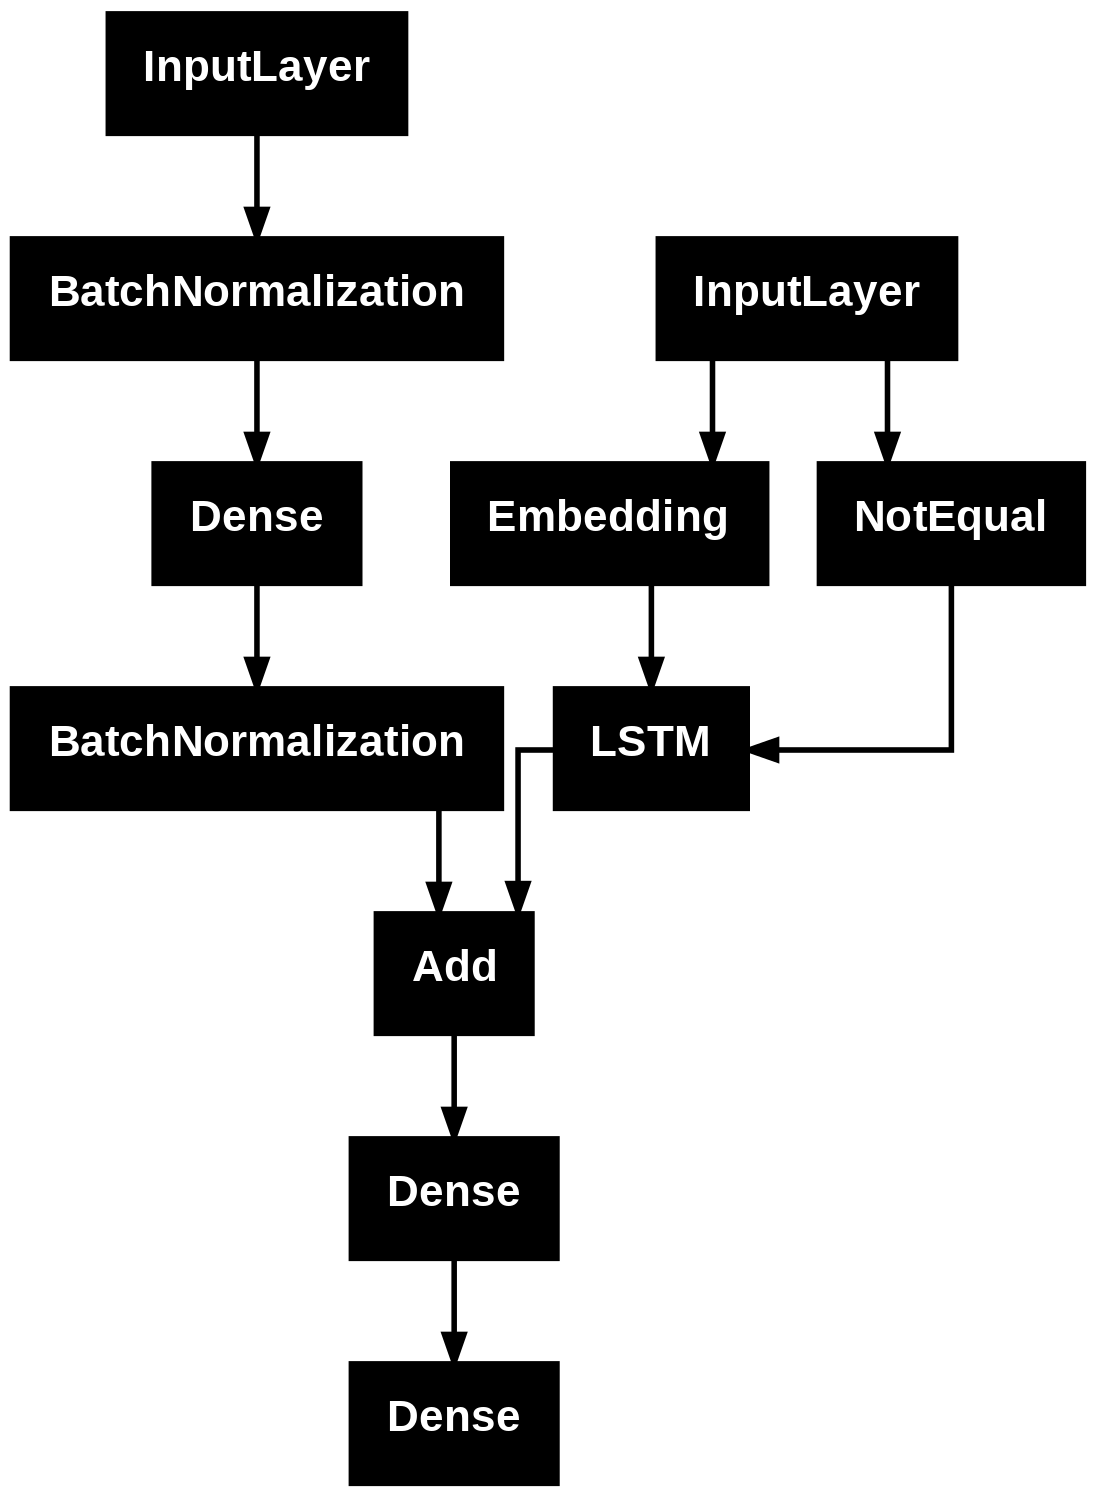

In [ ]:
plot_model(caption_model)

# Step - 13: Training the Model with Early Stopping and Learning Rate Scheduling

We train the model using the Adam optimizer and categorical cross-entropy loss while implementing early stopping to prevent overfitting. A learning rate scheduler is applied to gradually decrease the learning rate over epochs, ensuring stable convergence. The model is trained for up to 15 epochs with validation monitoring.

In [23]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

def lr_scheduler(epoch, lr):
    return float(lr * tf.math.exp(-0.6))

lr_schedule = LearningRateScheduler(lr_scheduler)

history = caption_model.fit(
    train_data_generator,
    steps_per_epoch=len(train_captions) // batch_size_train,
    validation_data=val_data_generator,
    validation_steps=len(val_captions) // batch_size_val,
    epochs=15,
    callbacks=[early_stopping, lr_schedule])

Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 1348s 11s/step - loss: 5.0130 - val_loss: 3.4945 - learning_rate: 0.0055
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 1342s 11s/step - loss: 2.9857 - val_loss: 3.1711 - learning_rate: 0.0030
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 1303s 10s/step - loss: 2.5674 - val_loss: 3.1263 - learning_rate: 0.0017
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 1298s 10s/step - loss: 2.3269 - val_loss: 3.1647 - learning_rate: 9.0718e-04
Epoch 5/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 1303s 10s/step - loss: 2.1804 - val_loss: 3.1785 - learning_rate: 4.9787e-04
Epoch 6/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 1342s 11s/step - loss: 2.1051 - val_loss: 3.2193 - learning_rate: 2.7324e-04


Fixed Data Generator

In [ ]:
# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

def lr_scheduler(epoch, lr):
    return float(lr * tf.math.exp(-0.6))

lr_schedule = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# Train the model
history = caption_model.fit(
    train_data_generator,
    steps_per_epoch=len(train_captions) // batch_size_train,
    validation_data=val_data_generator,
    validation_steps=len(val_captions) // batch_size_val,
    epochs=15,
    callbacks=[early_stopping, lr_schedule]
)


Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1306s 11s/step - loss: 5.0678 - val_loss: 3.5737 - learning_rate: 0.0055
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1252s 11s/step - loss: 3.0160 - val_loss: 3.2542 - learning_rate: 0.0030
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1242s 10s/step - loss: 2.5657 - val_loss: 3.2188 - learning_rate: 0.0017
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1275s 11s/step - loss: 2.3228 - val_loss: 3.2480 - learning_rate: 9.0718e-04
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1346s 11s/step - loss: 2.1896 - val_loss: 3.2773 - learning_rate: 4.9787e-04
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1416s 12s/step - loss: 2.0862 - val_loss: 3.3133 - learning_rate: 2.7324e-04


# Step - 14: Visualizing Training and Validation Loss

We plot the training and validation loss over epochs to analyze the model's learning process. This helps in identifying overfitting and assessing model performance improvements across iterations.

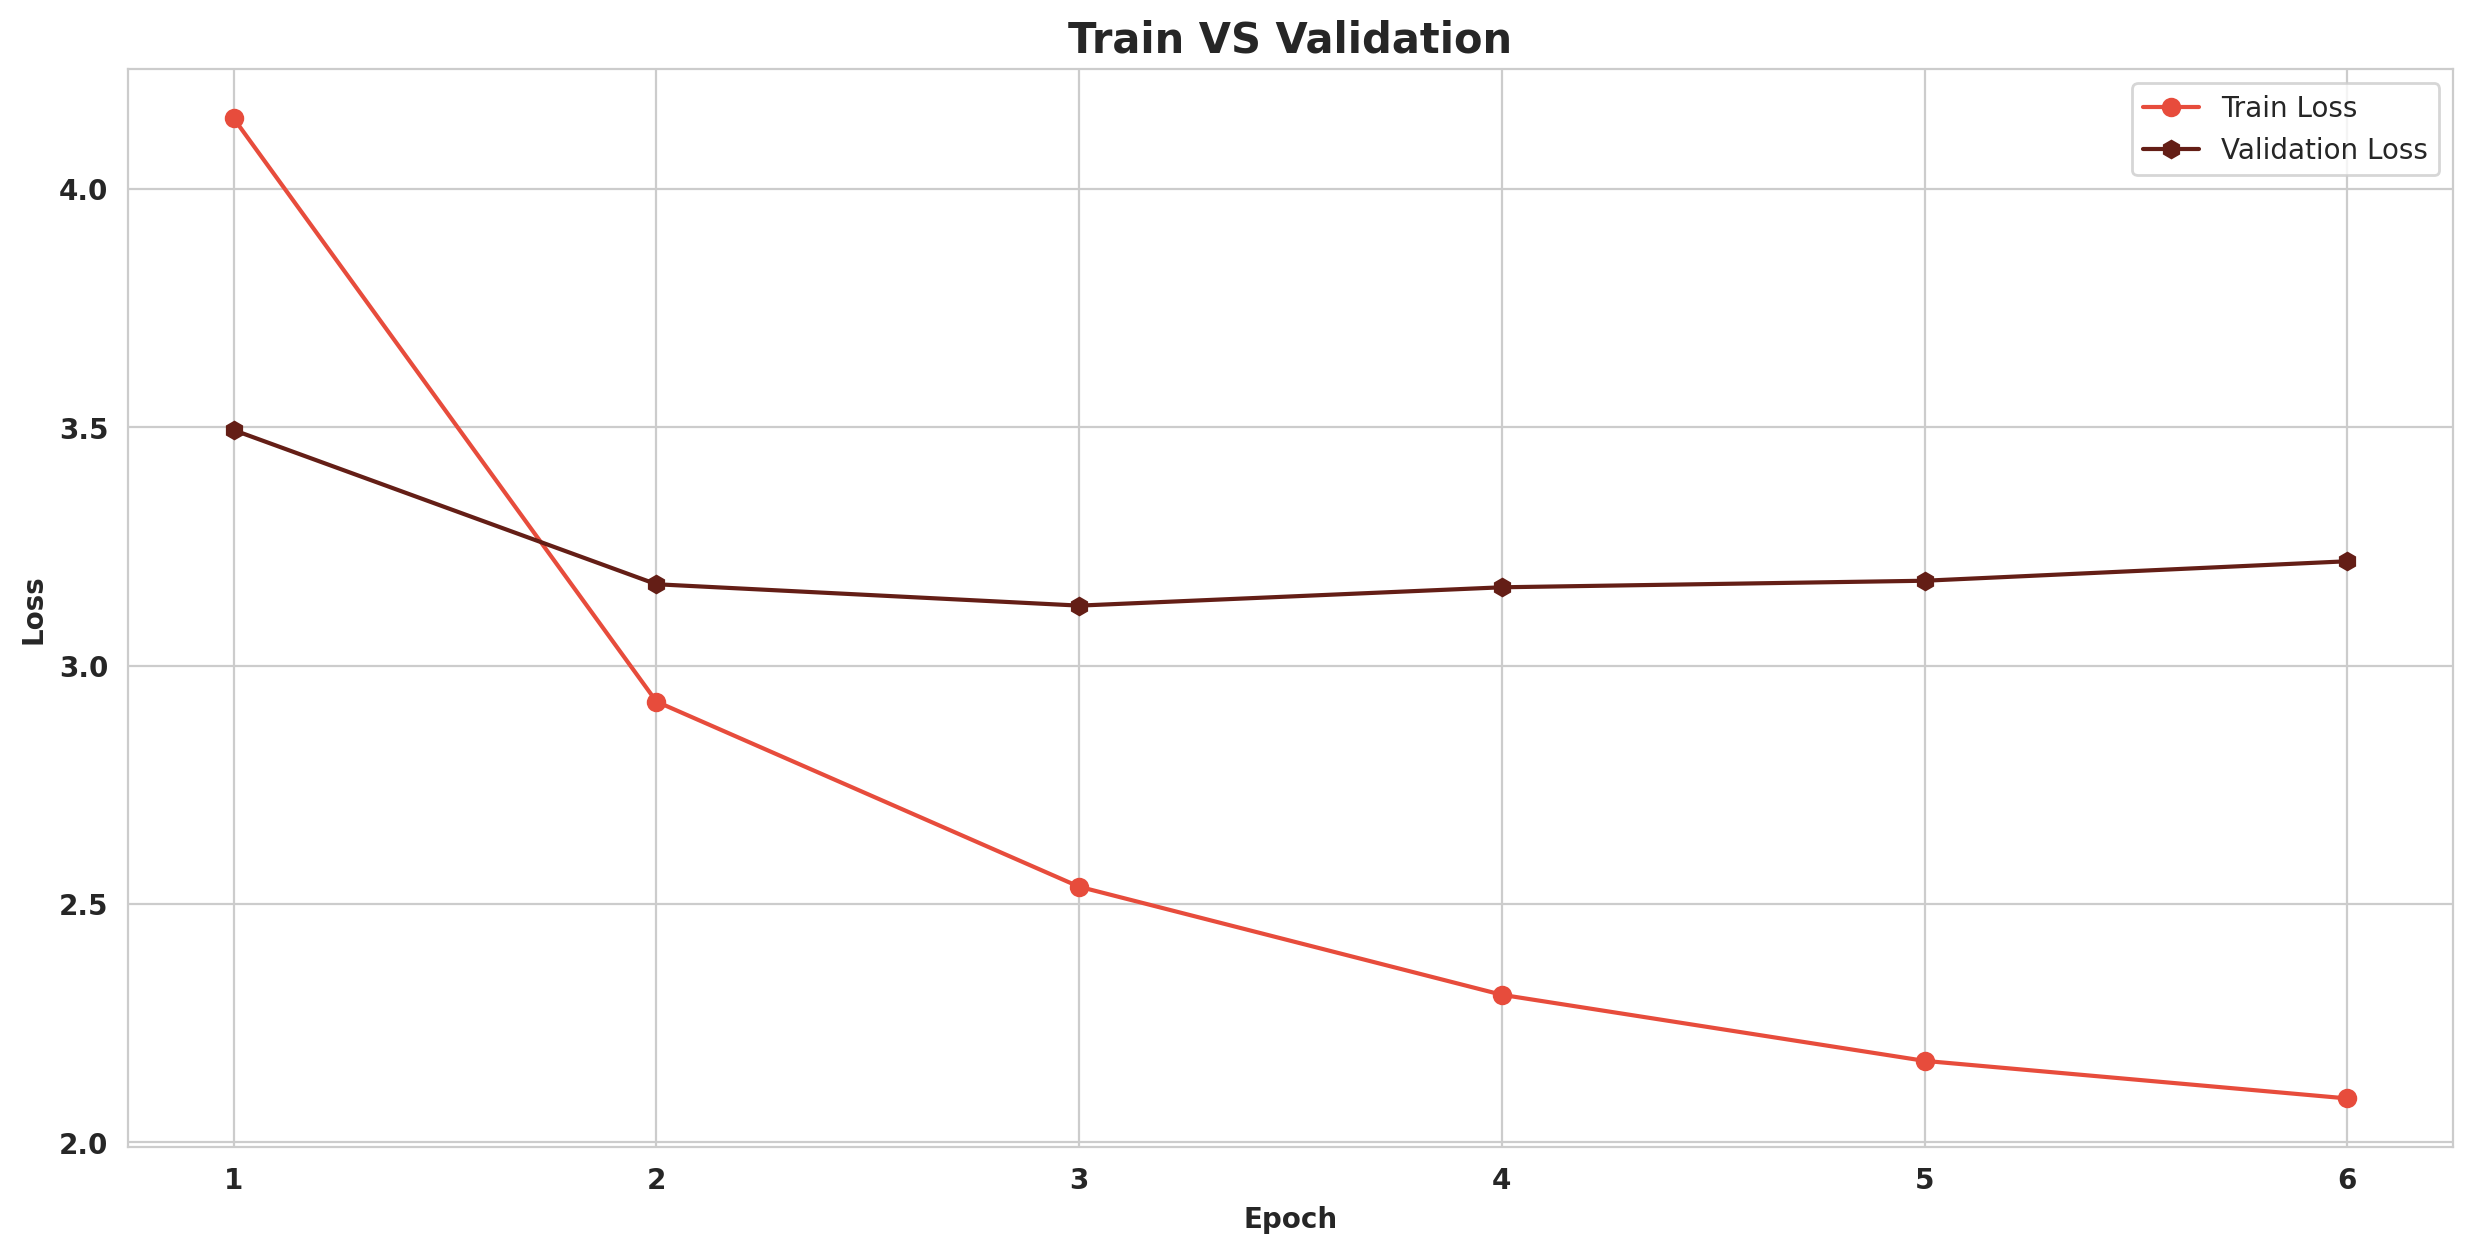

In [24]:
plt.figure(figsize=(15, 7), dpi=200)
sns.set_style('whitegrid')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['loss'], color='#E74C3C', marker='o')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['val_loss'], color='#641E16', marker='h')
plt.title('Train VS Validation', fontsize=15, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend(['Train Loss', 'Validation Loss'], loc='best')
plt.show()

# Step - 15: Generating Captions Using Greedy Search

We implement a greedy search algorithm to generate captions by predicting one word at a time. The model selects the word with the highest probability at each step until the end token is reached.

In [25]:
def greedy_generator(image_features):
    in_text = 'start '
    for _ in range(max_caption_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # now i will add padding post here
        # sequence = pad_sequences([sequence], maxlen=max_caption_length).reshape((1,max_caption_length), padding='post') # change
        sequence = pad_sequences([sequence], maxlen=max_caption_length).reshape((1,max_caption_length)) # original
        prediction = caption_model.predict([image_features.reshape(1,cnn_output_dim), sequence], verbose=0)
        idx = np.argmax(prediction)
        word = tokenizer.index_word[idx]
        in_text += ' ' + word
        if word == 'end':
            break

    in_text = in_text.replace('start ', '')
    in_text = in_text.replace(' end', '')

    return in_text

# Step - 16: Generating Captions Using Beam Search

We implement beam search to generate captions by exploring multiple possible sequences at each step. This method selects the top K probable sequences.

In [125]:
# image_features: pre-extracted CNN features for the image. K_beams: number of beams to keep at each step.
def beam_search_generator(image_features, K_beams = 3, log = True):
    start = [tokenizer.word_index['start']]
    start_word = [[start, 0.0]]
    for _ in range(max_caption_length):
        temp = []
        for s in start_word:
            sequence  = pad_sequences([s[0]], maxlen=max_caption_length).reshape((1,max_caption_length)) # Pad it to max_caption_length
            preds = caption_model.predict([image_features.reshape(1,cnn_output_dim), sequence], verbose=0) # Predict next word probabilities with the model
            word_preds = np.argsort(preds[0])[-K_beams:]
            for w in word_preds:
                next_cap, prob = s[0][:], s[1]
                next_cap.append(w)
                if log:
                    prob += np.log(preds[0][w]) # assign a probability to each K words
                else:
                    prob += preds[0][w]
                temp.append([next_cap, prob])

        start_word = temp
        start_word = sorted(start_word, reverse=False, key=lambda l: l[1]) # Sort all candidate sequences by probability
        start_word = start_word[-K_beams:]      # Keep only top K sequences for the next iteration

    start_word = start_word[-1][0]
    captions_ = [tokenizer.index_word[i] for i in start_word]  # Convert token indices back to words
    final_caption = []
    for i in captions_:
        if i != 'end':      # Remove the end token and stop the caption generation
            final_caption.append(i)
        else:
            break

    final_caption = ' '.join(final_caption[1:]) # Remove the start token and join the words into a single string
    return final_caption

# Step - 17: BLEU Score

It Computes the BLEU (Bilingual Evaluation Understudy) score a metric for evaluating the quality of text translations by comparing them to one or more reference translations.

In [126]:
import nltk
nltk.download('punkt')  # sometimes needed for BLEU tokenization
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def BLEU_score(actual_caps, greedy_cap, beam_cap):
    smoothie = SmoothingFunction().method4 # Creates a smoothing function to handle cases where n-grams are missing, preventing BLEU from being zero.

    # references: list of lists of tokens
    references = [cap.split() for cap in actual_caps]

    greedy_tokens = greedy_cap.split()
    beam_tokens = beam_cap.split()

    bleu1_greedy = corpus_bleu([references], [greedy_tokens], weights=(1,0,0,0), smoothing_function=smoothie)
    bleu2_greedy = corpus_bleu([references], [greedy_tokens], weights=(0.5,0.5,0,0), smoothing_function=smoothie)
    bleu3_greedy = corpus_bleu([references], [greedy_tokens], weights=(0.3,0.3,0.3,0), smoothing_function=smoothie) # tri grams
    bleu4_greedy = corpus_bleu([references], [greedy_tokens], weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie) # 4 grams

    bleu1_beam = corpus_bleu([references], [beam_tokens], weights=(1,0,0,0), smoothing_function=smoothie)
    bleu2_beam = corpus_bleu([references], [beam_tokens], weights=(0.5,0.5,0,0), smoothing_function=smoothie)
    bleu3_beam = corpus_bleu([references], [beam_tokens], weights=(0.3,0.3,0.3,0), smoothing_function=smoothie) # tri grams
    bleu4_beam = corpus_bleu([references], [beam_tokens], weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie) # 4 grams

    return {
        "Greedy": greedy_cap,
        "BLEU-1 Greedy": round(bleu1_greedy, 4),
        "BLEU-2 Greedy": round(bleu2_greedy, 4),
        "BLEU-3 Greedy": round(bleu3_greedy, 4),
        "BLEU-4 Greedy": round(bleu4_greedy, 4),
        "Beam": beam_cap,
        "BLEU-1 Beam": round(bleu1_beam, 4),
        "BLEU-2 Beam": round(bleu2_beam, 4),
        "BLEU-3 Beam": round(bleu3_beam, 4),
        "BLEU-4 Beam": round(bleu4_beam, 4),
    }


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Step -18: Generating Captions for Test Images using Greedy and Beam

We generate captions for all test images using the greedy search method. A progress bar is used to track the generation process efficiently.

Generate Test Image Caption Using Greedy Search

In [28]:
greedy_generated_captions = {}

pbar = tqdm_notebook(total=len(test_image_features), position=0, leave=True, colour='green')
for image_id in test_image_features:
    cap = greedy_generator(test_image_features[image_id])
    greedy_generated_captions[image_id] = cap
    pbar.update(1)

pbar.close()

  0%|          | 0/243 [00:00<?, ?it/s]

Generate Test Image Caption Using Beam Search

In [128]:
beam_generated_captions = {}

pbar = tqdm_notebook(total=len(test_image_features), position=0, leave=True, colour='green')
for image_id in test_image_features:
    cap = beam_search_generator(test_image_features[image_id])
    beam_generated_captions[image_id] = cap
    pbar.update(1)

pbar.close()

  0%|          | 0/243 [00:00<?, ?it/s]

# Step - 19: Visualizing Caption Generation Results

We randomly select images from the test set and display them alongside their actual captions, greedy search-generated captions and beam search-generated captions. The BLEU score evaluator is used to assess the quality of the generated captions.

Create dictionary of actual caption for test images

In [74]:
# Create dictionary of actual captions for test images
test_actual_captions = {}

for caption in test_captions:  # test_captions comes from your split
    image_id, cap_text = caption.split('\t')
    cap_text = cap_text.replace("start ", "").replace(" end", "").strip()
    if image_id not in test_actual_captions:
        test_actual_captions[image_id] = []
    test_actual_captions[image_id].append(cap_text)


Define the Visualization Function

In [129]:
from textwrap import wrap
from tensorflow.keras.utils import load_img

def visualization(data, greedy_caps, beam_caps, evaluator, num_images):
    keys = list(data.keys())
    samples = np.random.choice(keys, num_images, replace=False)

    # fig = plt.figure(figsize=(10, 4*num_images))
    fig = plt.figure(figsize=(10, 3*num_images), constrained_layout=True)
    plot_idx = 1
    plt.title("Evaluation Metric: BLEU-1 and BLEU-2", color = 'red')
    plt.grid(False)

    for img_id in samples:
        # Ground truth captions
        actual_caps = [c.replace('start ', '').replace(' end', '') for c in data[img_id]]

        # Predictions
        greedy_cap = greedy_caps[img_id]
        beam_cap = beam_caps[img_id]

        scores = evaluator(actual_caps, greedy_cap, beam_cap)

        # Load image
        img = load_img(images_directory + img_id, target_size=(160,160,3))

        # Image
        ax = fig.add_subplot(num_images, 2, plot_idx)
        ax.imshow(img)
        ax.axis('off')
        plot_idx += 1

        # Text
        ax = fig.add_subplot(num_images, 2, plot_idx)
        ax.axis('off')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)


        text = (
            f"Actual (one): {actual_caps[0]}\n\n"
            f"Greedy: {scores['Greedy']}\n"
            f"BLEU-1: {scores['BLEU-1 Greedy']}\n"
            f"BLEU-2: {scores['BLEU-2 Greedy']}\n\n"
            f"Beam: {scores['Beam']}\n"
            f"BLEU-1: {scores['BLEU-1 Beam']}\n"
            f"BLEU-2: {scores['BLEU-2 Beam']}"
        )

        ax.text(0.01, 0.99, text, fontsize=10, va='top', ha='left', wrap=True)
        # ax.text(0, 0.9, text, fontsize=10, va='top')
        plot_idx += 1

    plt.tight_layout()
    plt.show()


Call the Visualization Function

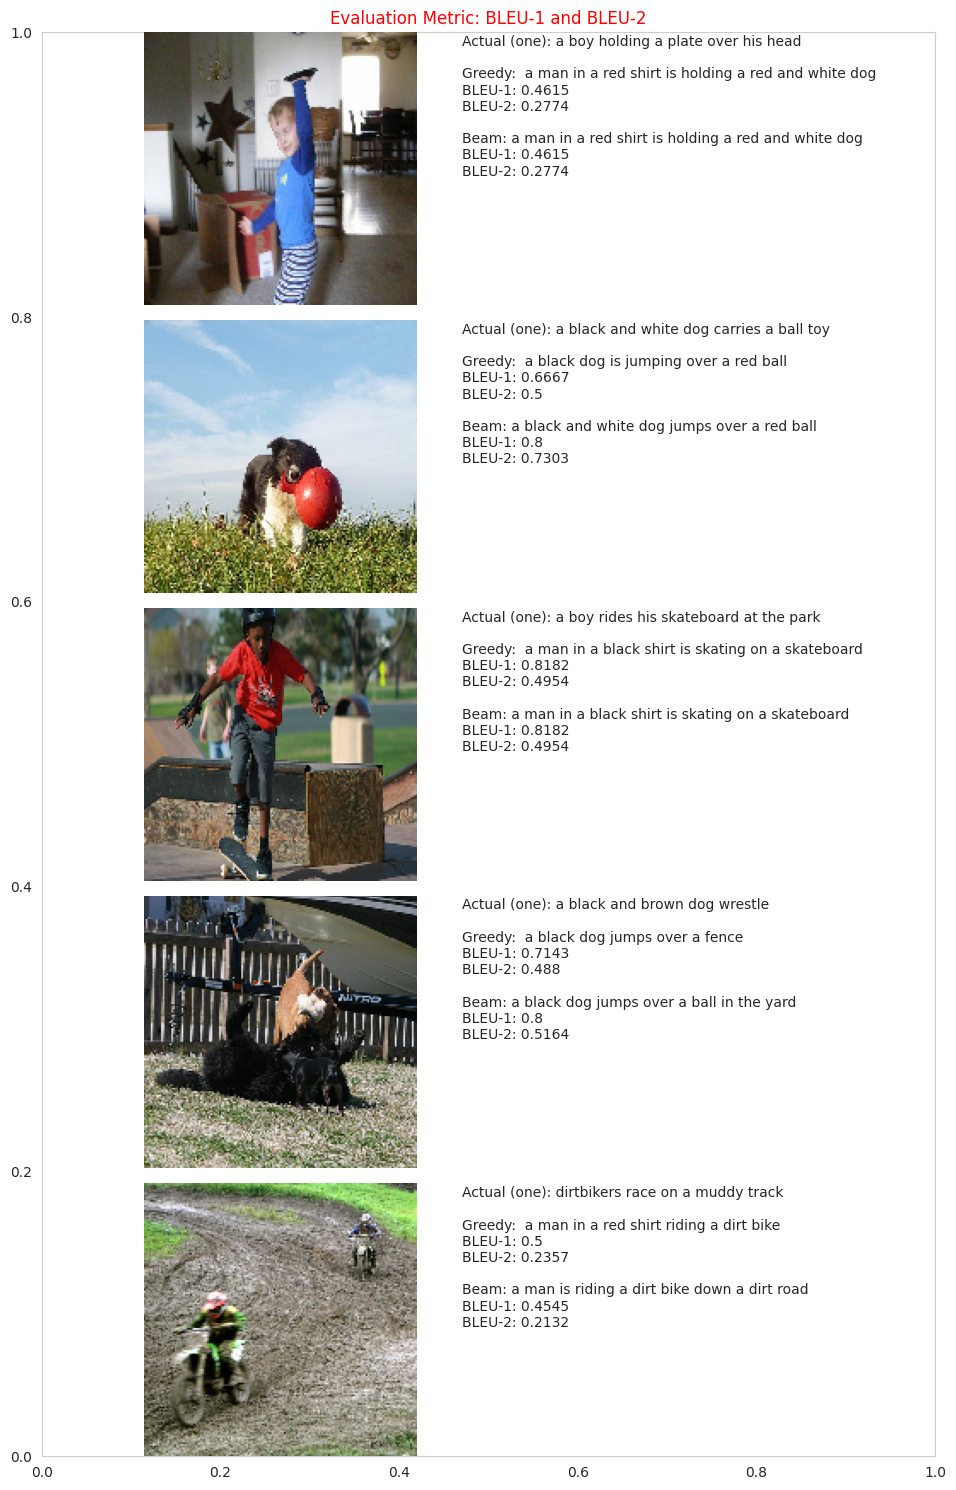

In [130]:
visualization(
    test_actual_captions,
    greedy_generated_captions,
    beam_generated_captions,
    BLEU_score,
    num_images=5
)


# Step - 20: CIDEr Score

We use CIDEr because it is specifically designed for measures how well a generated caption matches multiple human references using TF-IDF weighting, capturing informativeness and consensus. Unlike BLEU, which focuses only on n-gram overlap, CIDEr better reflects human judgment of caption quality.

- CIDEr score will help us to understand which caption generator(GREEDY, BEAM) generate more similar image caption  like reference (we can say human leveling)

In [145]:
!pip install git+https://github.com/salaniz/pycocoevalcap.git


  Cloning https://github.com/salaniz/pycocoevalcap.git to /tmp/pip-req-build-2qnjd32o
  Running command git clone --filter=blob:none --quiet https://github.com/salaniz/pycocoevalcap.git /tmp/pip-req-build-2qnjd32o
  Resolved https://github.com/salaniz/pycocoevalcap.git to commit a24f74c408c918f1f4ec34e9514bc8a76ce41ffd
  Preparing metadata (setup.py) ... done


In [143]:
from pycocoevalcap.cider.cider import Cider

def CIDEr_score_dataset(actual_caps_dict, greedy_caps_dict, beam_caps_dict):

    refs = {}
    hyps_greedy = {}
    hyps_beam = {}

    for i, img_id in enumerate(actual_caps_dict.keys()):
        refs[str(i)] = actual_caps_dict[img_id]
        hyps_greedy[str(i)] = [greedy_caps_dict[img_id]]
        hyps_beam[str(i)] = [beam_caps_dict[img_id]]

    cider = Cider()

    cider_greedy, _ = cider.compute_score(refs, hyps_greedy)
    cider_beam, _ = cider.compute_score(refs, hyps_beam)

    return {
        "CIDEr Greedy (Dataset)": round(cider_greedy, 4),
        "CIDEr Beam (Dataset)": round(cider_beam, 4)
    }

# calculate CIDEr score
cider_scores = CIDEr_score_dataset(test_actual_captions, greedy_generated_captions, beam_generated_captions)

print(cider_scores)

{'CIDEr Greedy (Dataset)': np.float64(0.5207), 'CIDEr Beam (Dataset)': np.float64(0.5742)}


Visualization with CIDEr

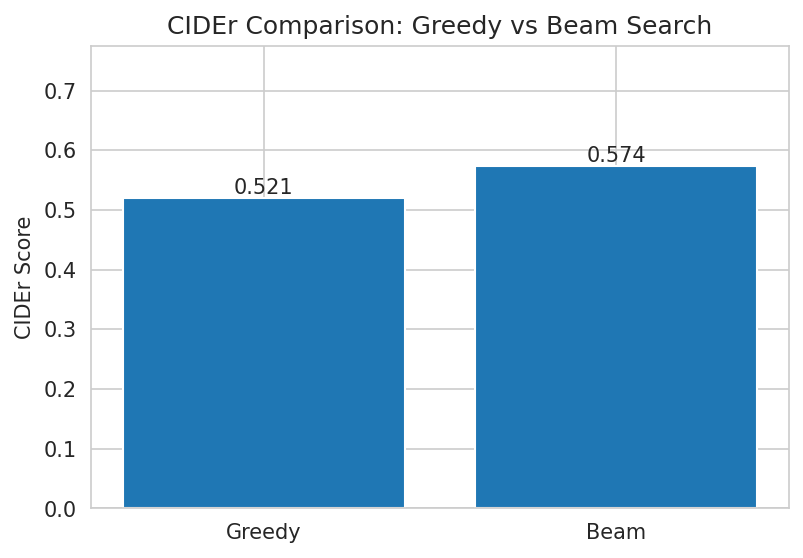

In [144]:
# define Visualization function for cider calculation
def plot_cider_scores(cider_scores):
    methods = ['Greedy', 'Beam']
    values = [
        cider_scores['CIDEr Greedy (Dataset)'],
        cider_scores['CIDEr Beam (Dataset)']
    ]

    plt.figure(figsize=(6,4), dpi=150)
    bars = plt.bar(methods, values)

    plt.ylabel("CIDEr Score")
    plt.title("CIDEr Comparison: Greedy vs Beam Search")

    # show value on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.ylim(0, max(values) + 0.2)
    plt.show()

plot_cider_scores(cider_scores)

# Step - 21: METEOR Score

In [134]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.translate.meteor_score import meteor_score

def METEOR_score(actual_caps, greedy_cap, beam_cap):
    """
    Compute METEOR score for a single image.

    Parameters:
    - actual_caps: list of reference captions (ground truth)
    - greedy_cap: generated caption (greedy search)
    - beam_cap: generated caption (beam search)

    Returns:
    - Dictionary with METEOR scores
    """

    # METEOR expects tokenized sentences
    references = [cap.split() for cap in actual_caps]

    greedy_score = meteor_score(references, greedy_cap.split())
    beam_score = meteor_score(references, beam_cap.split())

    return {
        "Greedy": greedy_cap,
        "METEOR Greedy": round(greedy_score, 4),
        "Beam": beam_cap,
        "METEOR Beam": round(beam_score, 4)
    }


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Following code is as like as visualization code above, just add meteor section here
- we have all 4 score of BLEU like BLEU - 1, 2, 3, 4
- unigrams, bigrams, tribgrams, 4-grams
- if we look at our result we will see score decrease as we move forword to value from BLEU-1 to BELU-4
- this is happen because BLEU-1 gives all weight to one word(very simple answer)
- this is all about for our model architecture and dataset limitation
- if we use mode dense layer in lstm architecture and used big dataset our model will perform better from these baseline(my current model)

In [135]:
from textwrap import wrap
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img
import numpy as np

def visualization(data, greedy_caps, beam_caps, evaluator, meteor, num_images):
    keys = list(data.keys())
    samples = np.random.choice(keys, num_images, replace=False)

    # fig = plt.figure(figsize=(10, 4*num_images))
    fig = plt.figure(figsize=(10, 3.5*num_images), constrained_layout=True)
    plot_idx = 1
    plt.title("Evaluation Metric: METEOR and BLEU", color = 'red')
    plt.grid(False)
    plt.tight_layout()

    for img_id in samples:
        # Ground truth captions
        actual_caps = [c.replace('start ', '').replace(' end', '') for c in data[img_id]]

        # Predictions
        greedy_cap = greedy_caps[img_id]
        beam_cap = beam_caps[img_id]

        scores = evaluator(actual_caps, greedy_cap, beam_cap)
        meteor_scores = meteor(actual_caps, greedy_cap, beam_cap)


        # Load image
        img = load_img(images_directory + img_id, target_size=(199,199,3))

        # Image
        ax = fig.add_subplot(num_images, 2, plot_idx)
        ax.imshow(img)
        ax.axis('off')
        plot_idx += 1

        # Text
        ax = fig.add_subplot(num_images, 2, plot_idx)
        ax.axis('off')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)


        text = (
            f"Actual (one): {actual_caps[0]}\n\n"
            f"Greedy: {scores['Greedy']}\n"
            f"BLEU-1: {scores['BLEU-1 Greedy']}\n"
            f"BLEU-2: {scores['BLEU-2 Greedy']}\n"
            f"BLEU-3: {scores['BLEU-3 Greedy']}\n"
            f"BLEU-4: {scores['BLEU-4 Greedy']}\n"
            f"METEOR: {meteor_scores['METEOR Greedy']}\n\n"
            f"Beam: {scores['Beam']}\n"
            f"BLEU-1: {scores['BLEU-1 Beam']}\n"
            f"BLEU-2: {scores['BLEU-2 Beam']}\n"
            f"BLEU-3: {scores['BLEU-3 Beam']}\n"
            f"BLEU-4: {scores['BLEU-4 Beam']}\n"
            f"METEOR: {meteor_scores['METEOR Beam']}"
        )

        ax.text(0.01, 0.99, text, fontsize=10, va='top', ha='left', wrap=True)

        # ax.text(0, 0.9, text, fontsize=10, va='top')
        plot_idx += 1

    plt.tight_layout()
    plt.show()


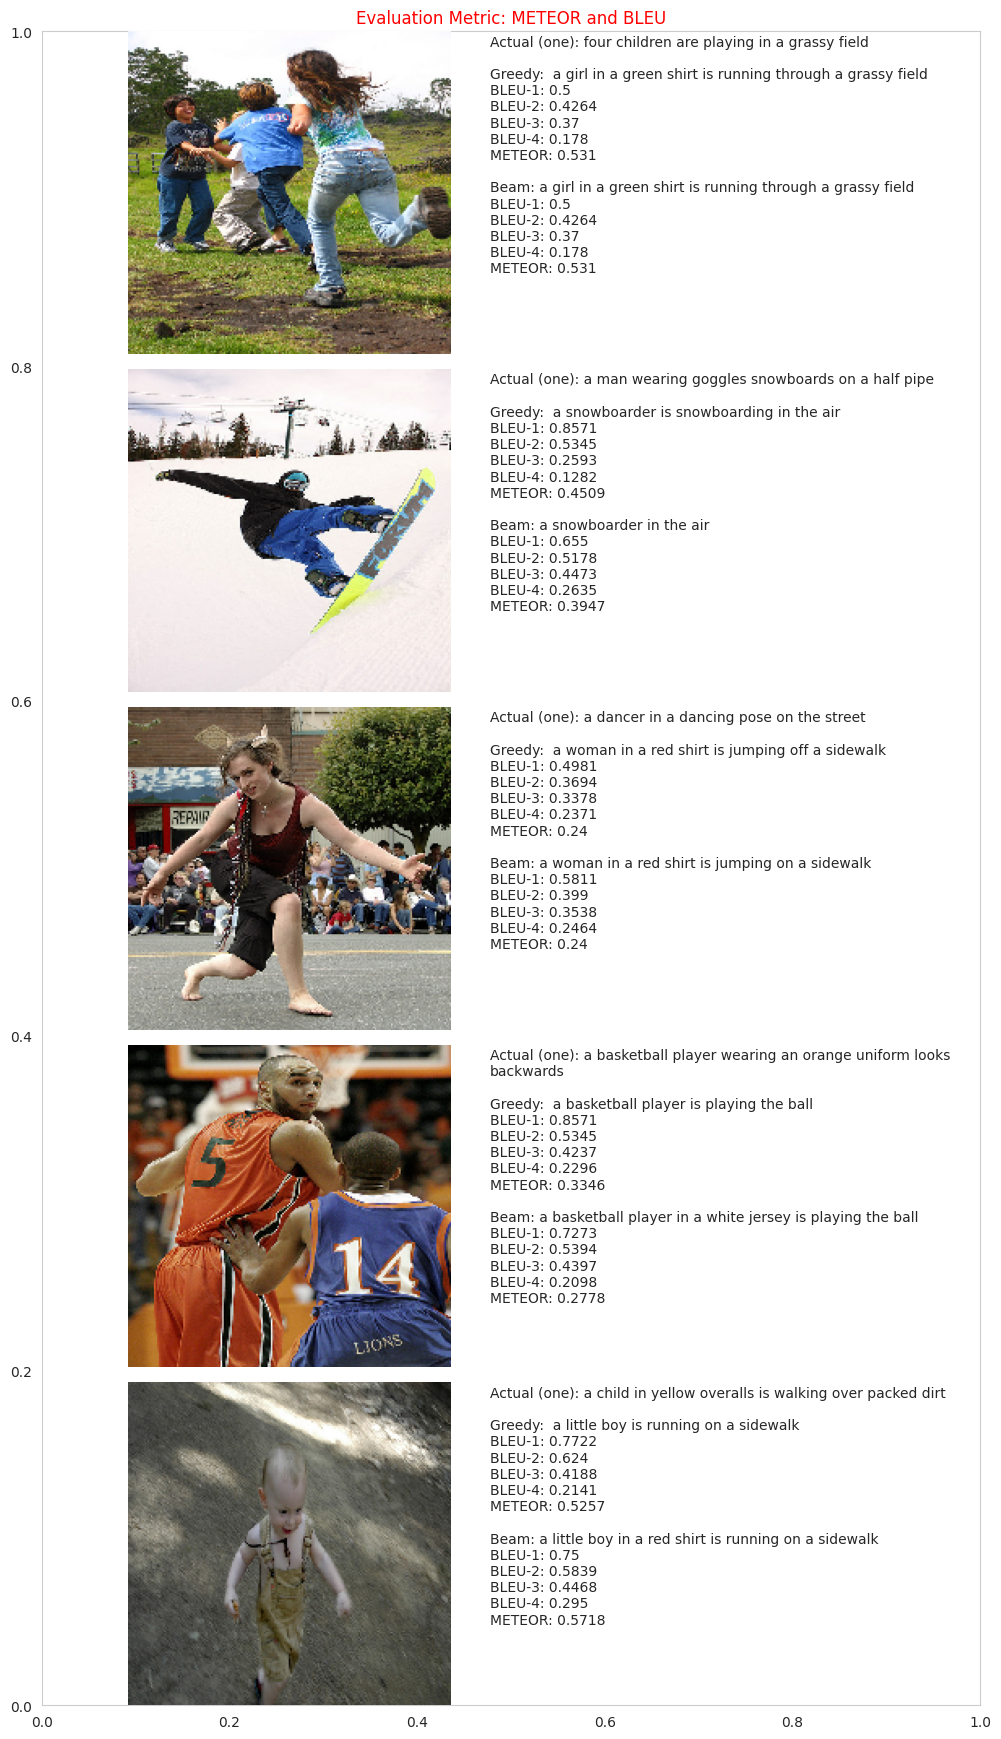

In [138]:
visualization(
    test_actual_captions,
    greedy_generated_captions,
    beam_generated_captions,
    BLEU_score,
    METEOR_score,
    num_images=5
)
